In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from itertools import product

# Ground state preparation

In [2]:
reps = [0, 1, 2]
num_sites = [3, 5, 8, 12]
couplings = [0, 0.5, 2, 5]
dd_enabled = ['std', 'dd']
folds = [1, 3, 5]

ref_data = dict()
for (n, h) in product(num_sites, couplings) :
    ref_energy = np.load(f'data/ref_{n}_{h}.npy')
    ref_data[(n, h)] = ref_energy

obs_data = dict()
for (rep, n, h, dd_str, f) in product(reps, num_sites, couplings, dd_enabled, folds) :
    energy = np.load(f'data/rep_{rep}_energy_{n}_{h}_{dd_str}_{f}.npy')
    obs_data[(rep, n, h, dd_str, f)] = energy

# print(ref_data, obs_data)

## No error mitigation.

In [3]:
baseline = dict()
for (rep, n, h) in product(reps, num_sites, couplings) :
    baseline[(rep,n, h)] = np.abs(obs_data[(rep, n, h, 'std', 1)] - ref_data[(n, h)])

# print(baseline)

## Dynamical Decoupling (DD)

In [4]:
ddem = dict()
ddim = dict()
for (rep, n, h) in product(reps, num_sites, couplings) :
    ddem[(rep, n, h)] = np.abs(obs_data[(rep, n, h, 'dd', 1)] - ref_data[(n, h)])
    percentage_improvement = 100 * (1-ddem[(rep, n, h)]/baseline[(rep, n, h)])
    ddim[(rep, n, h)] = float(percentage_improvement[0])
    print(f"rep={rep:3}, n={n:3}, h={h:5}:\t\t {ddim[(rep, n, h)]:05.2f}")

rep=  0, n=  3, h=    0:		 53.56
rep=  0, n=  3, h=  0.5:		 50.25
rep=  0, n=  3, h=    2:		 52.82
rep=  0, n=  3, h=    5:		 48.46
rep=  0, n=  5, h=    0:		 23.96
rep=  0, n=  5, h=  0.5:		 28.68
rep=  0, n=  5, h=    2:		 25.31
rep=  0, n=  5, h=    5:		 19.58
rep=  0, n=  8, h=    0:		 29.62
rep=  0, n=  8, h=  0.5:		 31.06
rep=  0, n=  8, h=    2:		 27.69
rep=  0, n=  8, h=    5:		 28.04
rep=  0, n= 12, h=    0:		 10.21
rep=  0, n= 12, h=  0.5:		 09.86
rep=  0, n= 12, h=    2:		 05.93
rep=  0, n= 12, h=    5:		 15.06
rep=  1, n=  3, h=    0:		 45.66
rep=  1, n=  3, h=  0.5:		 51.58
rep=  1, n=  3, h=    2:		 55.24
rep=  1, n=  3, h=    5:		 54.09
rep=  1, n=  5, h=    0:		 34.13
rep=  1, n=  5, h=  0.5:		 37.91
rep=  1, n=  5, h=    2:		 33.61
rep=  1, n=  5, h=    5:		 25.64
rep=  1, n=  8, h=    0:		 30.63
rep=  1, n=  8, h=  0.5:		 25.04
rep=  1, n=  8, h=    2:		 -11.83
rep=  1, n=  8, h=    5:		 -39.87
rep=  1, n= 12, h=    0:		 21.69
rep=  1, n= 12, h=  0.5:		 22.18
rep=  1,

## Zero-Noise Extrapolation (ZNE)
We experiment with both exponential curve fitting and Richardson (polynomial) extrapolation
and choose polynomial fitting as the better alternative.

In [5]:
def zne_exp(exp_vals, lambdas=(1.0,3.0,5.0)) :
    def exponential_model(l, A, B, C):
        return A + B * np.exp(-C * l)
    popt, _ = curve_fit(exponential_model, lambdas, exp_vals)
    zne_exponential = popt[0] + popt[1] # Equivalent to exponential_model(0, *popt)
    return zne_exponential

def zne_poly(exp_vals, lambdas=(1.0,3.0,5.0)) :
    coeffs = np.polyfit(lambdas, exp_vals, deg=len(lambdas)-1)
    zne_richardson = np.polyval(coeffs, 0)
    return zne_richardson

In [6]:
zneem = dict()
zneim = dict()

for (rep, n, h) in product(reps, num_sites, couplings) :
    zne_val = zne_poly([obs_data[(rep, n, h, 'std', 1)], obs_data[(rep, n, h, 'std', 3)], obs_data[(rep, n, h, 'std', 5)]])
    zneem[(rep, n, h)] = np.abs(zne_val - ref_data[(n, h)])
    percentage_improvement = 100 * (1-zneem[(rep, n, h)]/baseline[(rep, n, h)])
    zneim[(rep, n, h)] = float(percentage_improvement[0])
    print(f"rep={rep:3}, n={n:3}, h={h:5}:\t\t {zneim[(rep, n, h)]:05.2f}")

rep=  0, n=  3, h=    0:		 04.99
rep=  0, n=  3, h=  0.5:		 31.77
rep=  0, n=  3, h=    2:		 36.69
rep=  0, n=  3, h=    5:		 38.00
rep=  0, n=  5, h=    0:		 49.39
rep=  0, n=  5, h=  0.5:		 47.25
rep=  0, n=  5, h=    2:		 57.04
rep=  0, n=  5, h=    5:		 80.56
rep=  0, n=  8, h=    0:		 66.49
rep=  0, n=  8, h=  0.5:		 93.97
rep=  0, n=  8, h=    2:		 74.94
rep=  0, n=  8, h=    5:		 52.16
rep=  0, n= 12, h=    0:		 43.76
rep=  0, n= 12, h=  0.5:		 40.32
rep=  0, n= 12, h=    2:		 95.29
rep=  0, n= 12, h=    5:		 60.88
rep=  1, n=  3, h=    0:		 34.02
rep=  1, n=  3, h=  0.5:		 22.54
rep=  1, n=  3, h=    2:		 30.63
rep=  1, n=  3, h=    5:		 36.74
rep=  1, n=  5, h=    0:		 79.26
rep=  1, n=  5, h=  0.5:		 74.69
rep=  1, n=  5, h=    2:		 80.91
rep=  1, n=  5, h=    5:		 70.66
rep=  1, n=  8, h=    0:		 99.55
rep=  1, n=  8, h=  0.5:		 63.17
rep=  1, n=  8, h=    2:		 57.06
rep=  1, n=  8, h=    5:		 38.69
rep=  1, n= 12, h=    0:		 48.10
rep=  1, n= 12, h=  0.5:		 50.81
rep=  1, n

## Both methods (ZNE+DD)

In [7]:
ddzneem = dict()
ddzneim = dict()

for (rep, n, h) in product(reps, num_sites, couplings) :
    ddzne_val = zne_poly([obs_data[(rep, n, h, 'dd', 1)], obs_data[(rep, n, h, 'dd', 3)], obs_data[(rep, n, h, 'dd', 5)]])
    ddzneem[(rep, n, h)] = np.abs(ddzne_val - ref_data[(n, h)])
    percentage_improvement = 100 * (1-ddzneem[(rep, n, h)]/baseline[(rep, n, h)])
    ddzneim[(rep, n, h)] = float(percentage_improvement[0])
    print(f"rep={rep:3}, n={n:3}, h={h:5}:\t\t {ddzneim[(rep, n, h)]:05.2f}")

rep=  0, n=  3, h=    0:		 77.69
rep=  0, n=  3, h=  0.5:		 70.97
rep=  0, n=  3, h=    2:		 64.19
rep=  0, n=  3, h=    5:		 69.46
rep=  0, n=  5, h=    0:		 63.78
rep=  0, n=  5, h=  0.5:		 69.40
rep=  0, n=  5, h=    2:		 62.22
rep=  0, n=  5, h=    5:		 75.01
rep=  0, n=  8, h=    0:		 87.65
rep=  0, n=  8, h=  0.5:		 96.16
rep=  0, n=  8, h=    2:		 93.94
rep=  0, n=  8, h=    5:		 85.90
rep=  0, n= 12, h=    0:		 52.46
rep=  0, n= 12, h=  0.5:		 55.99
rep=  0, n= 12, h=    2:		 86.04
rep=  0, n= 12, h=    5:		 80.42
rep=  1, n=  3, h=    0:		 78.75
rep=  1, n=  3, h=  0.5:		 86.95
rep=  1, n=  3, h=    2:		 84.06
rep=  1, n=  3, h=    5:		 87.95
rep=  1, n=  5, h=    0:		 89.23
rep=  1, n=  5, h=  0.5:		 95.66
rep=  1, n=  5, h=    2:		 90.23
rep=  1, n=  5, h=    5:		 60.86
rep=  1, n=  8, h=    0:		 92.31
rep=  1, n=  8, h=  0.5:		 93.08
rep=  1, n=  8, h=    2:		 64.90
rep=  1, n=  8, h=    5:		 37.44
rep=  1, n= 12, h=    0:		 72.22
rep=  1, n= 12, h=  0.5:		 69.31
rep=  1, n

## Plotting results

In [8]:
color_dd     = '#66c2a5'
color_zne    = '#fc8d62'
color_dd_zne = '#8da0cb'

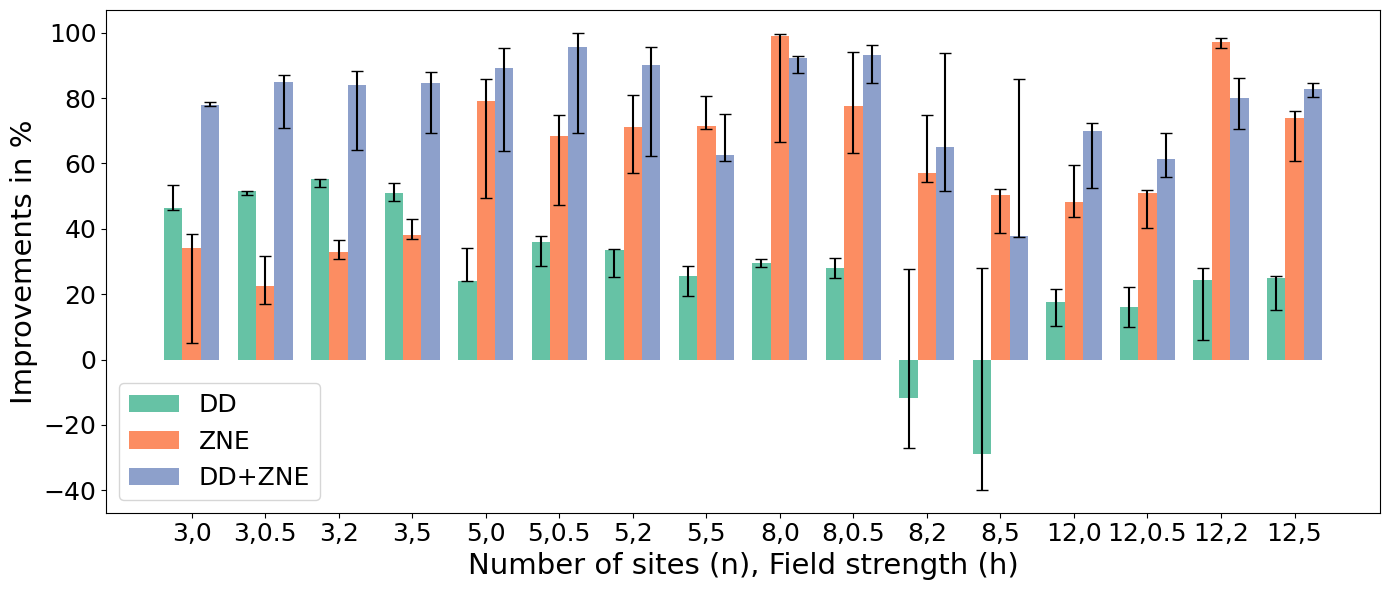

In [9]:
# 1. Prepare your 3 sets of 16 values
all_dd_values = [sorted(ddim[(rep, n, h)] for rep in reps) for (n, h) in product(num_sites, couplings)]
all_zne_values = [sorted(zneim[(rep, n, h)] for rep in reps) for (n, h) in product(num_sites, couplings)]
all_dd_zne_values = [sorted(ddzneim[(rep, n, h)] for rep in reps) for (n, h) in product(num_sites, couplings)]

dd_values = [a[1] for a in all_dd_values]
zne_values = [a[1] for a in all_zne_values]
dd_zne_values = [a[1] for a in all_dd_zne_values]

dd_errors = [[a[1]-a[0] for a in all_dd_values], [a[2]-a[1] for a in all_dd_values]]
zne_errors = [[a[1]-a[0] for a in all_zne_values], [a[2]-a[1] for a in all_zne_values]]
dd_zne_errors = [[a[1]-a[0] for a in all_dd_zne_values], [a[2]-a[1] for a in all_dd_zne_values]]

# Labels for the 16 groups
groups = [f'{n},{h}' for (n, h) in product(num_sites, couplings)]

# 2. Set up positions
x = np.arange(len(groups))  # The label locations
width = 0.25  # The width of the individual bars

fig, ax = plt.subplots(figsize=(14, 6))

# 3. Create the bars
# We offset each bar by the width to keep them grouped
rects1 = ax.bar(x - width, dd_values, width, yerr=dd_errors, label='DD', color=color_dd, capsize=4)
rects2 = ax.bar(x, zne_values, width, yerr=zne_errors, label='ZNE', color=color_zne, capsize=4)
rects3 = ax.bar(x + width, dd_zne_values, width, yerr=dd_zne_errors, label='DD+ZNE', color=color_dd_zne, capsize=4)

ax.set_xlabel('Number of sites (n), Field strength (h)', fontsize=21)
ax.set_ylabel('Improvements in %', fontsize=21)
# ax.set_title('Comparison of EM techniques for Ising Hamiltonian ground state preparation', fontsize=21)
ax.set_xticks(x)
ax.set_xticklabels(groups) # Rotated for better readability
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18, loc='best')

plt.tight_layout()
plt.savefig('ising_gsp.pdf')
plt.show()

# Hamiltonian simulation

In [10]:
reps = [0, 1, 2]
num_sites = [5, 12]
couplings = [0.5, 5]
dd_enabled = ['std', 'dd']
folds = [1, 3, 5]

ref_data = dict()
for (n, h) in product(num_sites, couplings) :
    ref_energy = np.load(f'data/evo_ref_{n}_{h}.npy')
    ref_data[(n, h)] = ref_energy

obs_data = dict()
for (rep, n, h, dd_str, f) in product(reps, num_sites, couplings, dd_enabled, folds) :
    energy = np.load(f'data/rep_{rep}_evo_energy_{n}_{h}_{dd_str}_{f}.npy')
    obs_data[(rep, n, h, dd_str, f)] = energy

# print(ref_data, obs_data)

## No error mitigation.

In [11]:
baseline = dict()
for (rep, n, h) in product(reps, num_sites, couplings) :
    baseline[(rep,n, h)] = np.abs(obs_data[(rep, n, h, 'std', 1)] - ref_data[(n, h)])

# print(baseline)

## Dynamical Decoupling (DD)

In [12]:
ddem = dict()
ddim = dict()
for (rep, n, h) in product(reps, num_sites, couplings) :
    ddem[(rep, n, h)] = np.abs(obs_data[(rep, n, h, 'dd', 1)] - ref_data[(n, h)])
    percentage_improvement = 100 * (1-ddem[(rep, n, h)]/baseline[(rep, n, h)])
    ddim[(rep, n, h)] = float(percentage_improvement)
    print(f"rep={rep:3}, n={n:3}, h={h:5}:\t\t {ddim[(rep, n, h)]:05.2f}")

rep=  0, n=  5, h=  0.5:		 -180.36
rep=  0, n=  5, h=    5:		 42.53
rep=  0, n= 12, h=  0.5:		 -289.10
rep=  0, n= 12, h=    5:		 39.41
rep=  1, n=  5, h=  0.5:		 -105.64
rep=  1, n=  5, h=    5:		 33.99
rep=  1, n= 12, h=  0.5:		 -105.16
rep=  1, n= 12, h=    5:		 26.26
rep=  2, n=  5, h=  0.5:		 -101.42
rep=  2, n=  5, h=    5:		 36.28
rep=  2, n= 12, h=  0.5:		 -106.41
rep=  2, n= 12, h=    5:		 28.06


## Zero-Noise Extrapolation (ZNE)
We experiment with both exponential curve fitting and Richardson (polynomial) extrapolation
and choose polynomial fitting as the better alternative.

In [13]:
zneem = dict()
zneim = dict()

for (rep, n, h) in product(reps, num_sites, couplings) :
    zne_val = zne_poly([obs_data[(rep, n, h, 'std', 1)], obs_data[(rep, n, h, 'std', 3)], obs_data[(rep, n, h, 'std', 5)]])
    zneem[(rep, n, h)] = np.abs(zne_val - ref_data[(n, h)])
    percentage_improvement = 100 * (1-zneem[(rep, n, h)]/baseline[(rep, n, h)])
    zneim[(rep, n, h)] = float(percentage_improvement)
    print(f"rep={rep:3}, n={n:3}, h={h:5}:\t\t {zneim[(rep, n, h)]:05.2f}")

rep=  0, n=  5, h=  0.5:		 -76.02
rep=  0, n=  5, h=    5:		 -131.74
rep=  0, n= 12, h=  0.5:		 32.21
rep=  0, n= 12, h=    5:		 -65.48
rep=  1, n=  5, h=  0.5:		 -13.08
rep=  1, n=  5, h=    5:		 -70.97
rep=  1, n= 12, h=  0.5:		 -6.91
rep=  1, n= 12, h=    5:		 -64.23
rep=  2, n=  5, h=  0.5:		 -13.45
rep=  2, n=  5, h=    5:		 -69.98
rep=  2, n= 12, h=  0.5:		 -12.88
rep=  2, n= 12, h=    5:		 -59.40


## Both methods (ZNE+DD)

In [14]:
ddzneem = dict()
ddzneim = dict()

for (rep, n, h) in product(reps, num_sites, couplings) :
    ddzne_val = zne_poly([obs_data[(rep, n, h, 'dd', 1)], obs_data[(rep, n, h, 'dd', 3)], obs_data[(rep, n, h, 'dd', 5)]])
    ddzneem[(rep, n, h)] = np.abs(ddzne_val - ref_data[(n, h)])
    percentage_improvement = 100 * (1-ddzneem[(rep, n, h)]/baseline[(rep, n, h)])
    ddzneim[(rep, n, h)] = float(percentage_improvement)
    print(f"rep={rep:3}, n={n:3}, h={h:5}:\t\t {ddzneim[(rep, n, h)]:05.2f}")

rep=  0, n=  5, h=  0.5:		 99.20
rep=  0, n=  5, h=    5:		 52.48
rep=  0, n= 12, h=  0.5:		 17.61
rep=  0, n= 12, h=    5:		 56.81
rep=  1, n=  5, h=  0.5:		 -20.69
rep=  1, n=  5, h=    5:		 45.52
rep=  1, n= 12, h=  0.5:		 17.61
rep=  1, n= 12, h=    5:		 42.71
rep=  2, n=  5, h=  0.5:		 19.75
rep=  2, n=  5, h=    5:		 48.14
rep=  2, n= 12, h=  0.5:		 00.49
rep=  2, n= 12, h=    5:		 47.24


## Plotting results

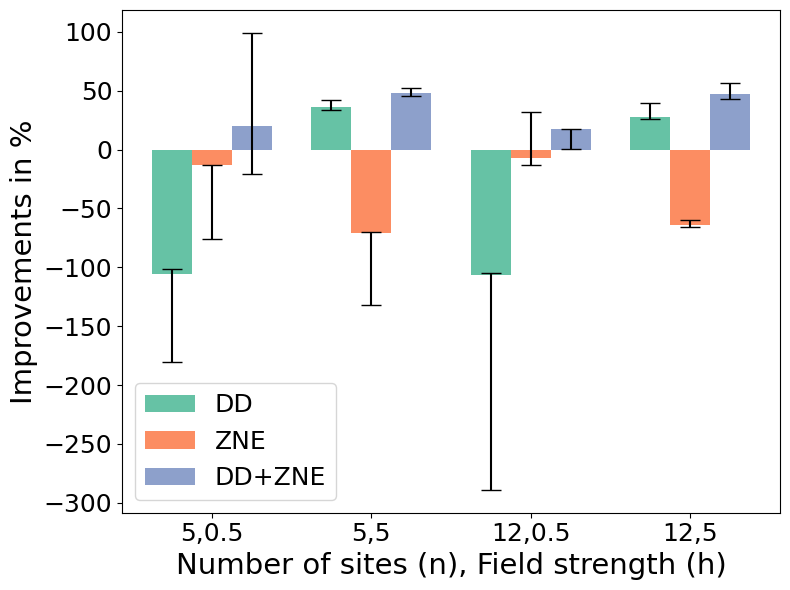

In [15]:
# 1. Prepare your 3 sets of 16 values
all_dd_values = [sorted(ddim[(rep, n, h)] for rep in reps) for (n, h) in product(num_sites, couplings)]
all_zne_values = [sorted(zneim[(rep, n, h)] for rep in reps) for (n, h) in product(num_sites, couplings)]
all_dd_zne_values = [sorted(ddzneim[(rep, n, h)] for rep in reps) for (n, h) in product(num_sites, couplings)]

dd_values = [a[1] for a in all_dd_values]
zne_values = [a[1] for a in all_zne_values]
dd_zne_values = [a[1] for a in all_dd_zne_values]

dd_errors = [[a[1]-a[0] for a in all_dd_values], [a[2]-a[1] for a in all_dd_values]]
zne_errors = [[a[1]-a[0] for a in all_zne_values], [a[2]-a[1] for a in all_zne_values]]
dd_zne_errors = [[a[1]-a[0] for a in all_dd_zne_values], [a[2]-a[1] for a in all_dd_zne_values]]

# Labels for the 16 groups
groups = [f'{n},{h}' for (n, h) in product(num_sites, couplings)]

# 2. Set up positions
x = np.arange(len(groups))  # The label locations
width = 0.25  # The width of the individual bars

fig, ax = plt.subplots(figsize=(8, 6))

# 3. Create the bars
# We offset each bar by the width to keep them grouped
rects1 = ax.bar(x - width, dd_values, width, yerr=dd_errors, label='DD', color=color_dd, capsize=7)
rects2 = ax.bar(x, zne_values, width, yerr=zne_errors, label='ZNE', color=color_zne, capsize=7)
rects3 = ax.bar(x + width, dd_zne_values, width, yerr=dd_zne_errors, label='DD+ZNE', color=color_dd_zne, capsize=7)

ax.set_xlabel('Number of sites (n), Field strength (h)', fontsize=21)
ax.set_ylabel('Improvements in %', fontsize=21)
# ax.set_title('Comparison of EM techniques for Ising Hamiltonian simulation', fontsize=21)
ax.set_xticks(x)
ax.set_xticklabels(groups) # Rotated for better readability
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18, loc='best')

plt.tight_layout()
plt.savefig('ising_evo.pdf')
plt.show()